In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv('anime.csv')
df.shape

(12294, 7)

In [44]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [45]:
df['type'].unique()

array(['Movie', 'TV', 'OVA', 'Special', 'Music', 'ONA', nan], dtype=object)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [47]:
df.describe()

,anime_id,rating,members
count,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,6.473902,1.807134e+04
std,11455.294701,1.026746,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,3484.250000,5.880000,2.250000e+02
50%,10260.500000,6.570000,1.550000e+03
75%,24794.500000,7.180000,9.437000e+03
max,34527.000000,10.000000,1.013917e+06


- "episode" column contains numbers but in a object form, and also contains 'unknown' like values need to convert to 'nan' then handel missing value then convert it to a numerical data typed column

In [48]:
df["episodes"] = df["episodes"].replace("Unknown", np.nan)

In [49]:
df['episodes'].unique()

array(['1', '64', '51', '24', '10', '148', '110', '13', '201', '25', '22',
       '75', '4', '26', '12', '27', '43', '74', '37', '2', '11', '99',
       nan, '39', '101', '47', '50', '62', '33', '112', '23', '3', '94',
       '6', '8', '14', '7', '40', '15', '203', '77', '291', '120', '102',
       '96', '38', '79', '175', '103', '70', '153', '45', '5', '21', '63',
       '52', '28', '145', '36', '69', '60', '178', '114', '35', '61',
       '34', '109', '20', '9', '49', '366', '97', '48', '78', '358',
       '155', '104', '113', '54', '167', '161', '42', '142', '31', '373',
       '220', '46', '195', '17', '1787', '73', '147', '127', '16', '19',
       '98', '150', '76', '53', '124', '29', '115', '224', '44', '58',
       '93', '154', '92', '67', '172', '86', '30', '276', '59', '72',
       '330', '41', '105', '128', '137', '56', '55', '65', '243', '193',
       '18', '191', '180', '91', '192', '66', '182', '32', '164', '100',
       '296', '694', '95', '68', '117', '151', '130', '87',

In [50]:
df['episodes'] = pd.to_numeric(df['episodes'], errors='coerce')

In [51]:
df['episodes'].isna().sum()

np.int64(340)

In [52]:
median_episodes = df['episodes'].median()
df['episodes'] = df['episodes'].fillna(median_episodes)

In [53]:
df['episodes'].isna().sum()

np.int64(0)

In [54]:
df['episodes'] = df['episodes'].astype(int)

In [55]:
df['episodes'].dtype

dtype('int64')

In [56]:
df.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.000000,12064.000000,1.229400e+04
mean,14058.221653,12.095412,6.473902,1.807134e+04
std,11455.294701,46.244062,1.026746,5.482068e+04
min,1.000000,1.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.880000,2.250000e+02
50%,10260.500000,2.000000,6.570000,1.550000e+03
75%,24794.500000,12.000000,7.180000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


In [57]:
df.isna().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [58]:
rows_with_nan = df[df.isna().any(axis=1)]
print(rows_with_nan)

       anime_id                                               name  \
2844      33242          IS: Infinite Stratos 2 - Infinite Wedding   
3541      33589                                      ViVid Strike!   
6040      29765                                  Metropolis (2009)   
6646      32695                                       Match Shoujo   
7018      33187                                   Katsudou Shashin   
...         ...                                                ...   
12274     34492  Nuki Doki! Tenshi to Akuma no Sakusei Battle -...   
12279     34491                       Sagurare Otome The Animation   
12280     34312                                       Saimin Class   
12282     34388                    Shikkoku no Shaga The Animation   
12285     34399                                   Taimanin Asagi 3   

                              genre     type  episodes  rating  members  
2844                            NaN  Special         1    7.15     6604  
3541       

In [59]:
df['genre'] = df['genre'].fillna('Unknown')

In [60]:
df[['type', 'episodes']].head(10)

,type,episodes
0,Movie,1
1,TV,64
2,TV,51
3,TV,24
4,TV,51
5,TV,10
6,TV,148
7,OVA,110
8,Movie,1
9,TV,13


In [63]:
df.loc[(df['type'].isna()) & (df['episodes'] == 1), 'type'] = 'Movie'
df['type'] = df['type'].fillna(df['type'].mode()[0])

In [62]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [64]:
df.isna().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

- all the missing values are handeled
- imputed either by mode median or 'unknow'

In [65]:
df.duplicated().sum()

np.int64(0)

- so there are no duplicates

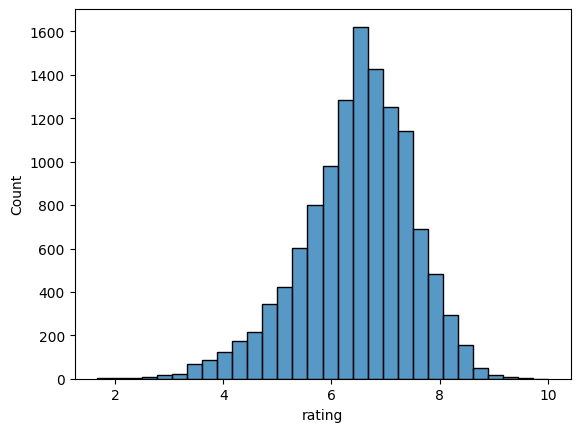

In [66]:
sns.histplot(df['rating'], bins=30)
plt.show()

- this describes the rati9ng distribution

In [67]:
df.nlargest(10,'members')[['name','rating','members']]

,name,rating,members
40,Death Note,8.71,1013917
86,Shingeki no Kyojin,8.54,896229
804,Sword Art Online,7.83,893100
1,Fullmetal Alchemist: Brotherhood,9.26,793665
159,Angel Beats!,8.39,717796
19,Code Geass: Hangyaku no Lelouch,8.83,715151
841,Naruto,7.81,683297
3,Steins;Gate,9.17,673572
445,Mirai Nikki (TV),8.07,657190
131,Toradora!,8.45,633817


- this shows the top 10 anme's bby popularity

In [68]:
df['type'].value_counts()

type
TV         3812
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Name: count, dtype: int64

<Axes: xlabel='members', ylabel='rating'>

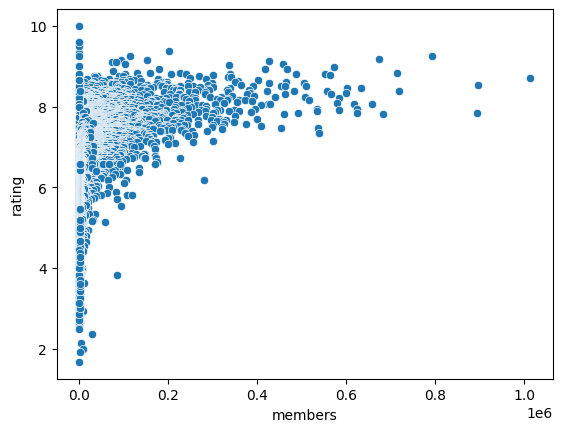

In [69]:
sns.scatterplot(
    data=df,
    x='members',
    y='rating'
)

- this shows that popular anime recive heigher ratings 

In [72]:
df.groupby('type')['rating'].mean()

type
Movie      6.323531
Music      5.588996
ONA        5.653141
OVA        6.376750
Special    6.523640
TV         6.890008
Name: rating, dtype: float64

<Axes: >

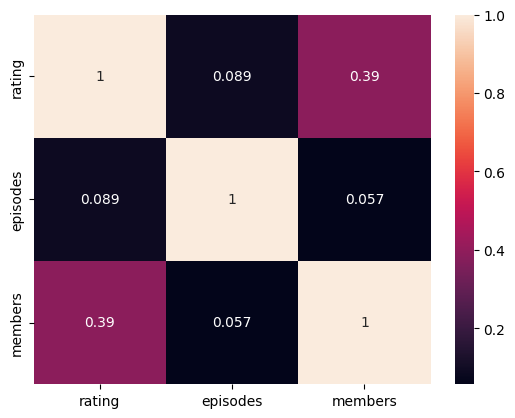

In [74]:
num_cols = ['rating','episodes','members']

sns.heatmap(
    df[num_cols].corr(),
    annot=True
)

- rating and members are a little bit corelated

In [75]:
df.columns

Index(['anime_id', 'name', 'genre', 'type', 'episodes', 'rating', 'members'], dtype='object')

#### Feature Extraction:

In [76]:
from sklearn.preprocessing import MultiLabelBinarizer

In [77]:
genres = df['genre'].str.split(', ')

In [79]:
mlb = MultiLabelBinarizer()

genre_features = mlb.fit_transform(genres)

In [82]:
genre_features


array([[0, 0, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [93]:
genre_df = pd.DataFrame(
    genre_features,
    columns=mlb.classes_,
    index=df.index
)

In [106]:
genre_df.head()

,Action,Adventure,Cars,Comedy,Dementia,Demons,Drama,Ecchi,Fantasy,Game,...,Slice of Life,Space,Sports,Super Power,Supernatural,Thriller,Unknown,Vampire,Yaoi,Yuri
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,1,1,0,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:
type_df = pd.get_dummies(
    df['type'],
    prefix='type',
    dtype=int
)

In [107]:
type_df.head()

,type_Movie,type_Music,type_ONA,type_OVA,type_Special,type_TV
0,1,0,0,0,0,0
1,0,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,0,0,0,0,0,1


scaling 

In [109]:
df_scaled = df[["rating", "members", "episodes"]].copy()

In [111]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

In [112]:
df_scaled['episodes'] = scaler.fit_transform(
    df_scaled[['episodes']]
)
df_scaled['rating'] = scaler.fit_transform(
    df_scaled[['rating']]
)
df_scaled['members'] = scaler.fit_transform(
    df_scaled[['members']]
)

In [113]:
df_scaled.head()

,rating,members,episodes
0,0.924370,0.197872,0.000000
1,0.911164,0.782770,0.034673
2,0.909964,0.112689,0.027518
3,0.900360,0.664325,0.012658
4,0.899160,0.149186,0.027518


In [114]:
x = pd.concat(
    [
        genre_df,
        type_df,
        df_scaled
    ],
    axis=1
)

#### Recommendation System:

In [116]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(x)

In [117]:
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=df['name'],
    columns=df['name']
)

In [119]:
def recommend_anime(anime_name, top_n=10):
    
    if anime_name not in similarity_df.index:
        return "Anime not found"

    scores = similarity_df.loc[anime_name]

    recommendations = (
        scores
        .sort_values(ascending=False)
        .iloc[1:top_n+1]
    )

    return recommendations

In [120]:
recommend_anime("Naruto")

name
Naruto: Shippuuden        0.997444
Katekyo Hitman Reborn!    0.911988
Dragon Ball Z             0.872958
Bleach                    0.856414
Dragon Ball Kai           0.855801
Dragon Ball Super         0.853197
Medaka Box                0.852548
Tenjou Tenge              0.851757
Medaka Box Abnormal       0.850534
Dragon Ball Kai (2014)    0.849937
Name: Naruto, dtype: float64

Threshold-Based Recommendations

In [121]:
def recommend_threshold(anime_name, threshold=0.70):
    
    if anime_name not in similarity_df.index:
        return "Anime not found"

    scores = similarity_df.loc[anime_name]

    recommendations = scores[
        scores >= threshold
    ].sort_values(ascending=False)

    recommendations = recommendations.drop(anime_name)

    return recommendations

In [125]:
recommend_threshold(
    "Naruto",
    threshold=0.80
)

name
Naruto: Shippuuden                                                           0.997444
Katekyo Hitman Reborn!                                                       0.911988
Dragon Ball Z                                                                0.872958
Bleach                                                                       0.856414
Dragon Ball Kai                                                              0.855801
Dragon Ball Super                                                            0.853197
Medaka Box                                                                   0.852548
Tenjou Tenge                                                                 0.851757
Medaka Box Abnormal                                                          0.850534
Dragon Ball Kai (2014)                                                       0.849937
Boku no Hero Academia                                                        0.841899
Shijou Saikyou no Deshi Kenichi                  

In [123]:
anime = "Naruto"

for t in [0.9, 0.8, 0.7, 0.6]:
    
    count = len(
        recommend_threshold(
            anime,
            threshold=t
        )
    )

    print(f"Threshold={t}: {count}")

Threshold=0.9: 2
Threshold=0.8: 32
Threshold=0.7: 125
Threshold=0.6: 502


manually Analyze the performance of the recommendation system

Check:
- Similar genres recommended
- Similar ratings
- Similar format (TV vs Movie)
- Bad Signs
- Random anime with same rating
- Different genres
- Similarity dominated by episodes

In [126]:
recommend_anime("Death Note")

name
Higurashi no Naku Koro ni Kai        0.889515
Mousou Dairinin                      0.884710
Higurashi no Naku Koro ni            0.834382
Death Note Rewrite                   0.803366
Mirai Nikki (TV)                     0.801117
Jigoku Shoujo Mitsuganae             0.790425
Yakushiji Ryouko no Kaiki Jikenbo    0.781085
Saint Luminous Jogakuin              0.774807
Boku dake ga Inai Machi              0.759300
Zankyou no Terror                    0.745931
Name: Death Note, dtype: float64

A content-based recommendation system was developed using genre, type, rating, and episode count features. Multi-label binarization was applied to genre data, one-hot encoding to type, and numerical features were normalized using MinMax scaling. Cosine similarity was used to measure similarity between anime. Experimental analysis showed that thresholds between 0.7 and 0.8 produced relevant recommendations while maintaining a reasonable recommendation list size.

#### Interview Questions:

1] Can you explain the difference between user-based and item-based collaborative filtering?

- User-Based Collaborative Filtering Recommend items liked by users who are similar to the target user.
- It find users similar to the target user and look at what those users liked and recommend those items.

- Item-Based Collaborative Filtering recommend items similar to items the user already likes.
- Compute similarity between items then find items similar to those the user liked recommend those items.

User-based collaborative filtering recommends items by finding users with similar preferences and suggesting items they have liked. Item-based collaborative filtering recommends items similar to those the user has already liked. Item-based methods are generally more scalable and stable because item similarities change less frequently than user preferences.

2] What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation technique that predicts a user's interests by analyzing the preferences and behaviors of many users.

It assumes users with similar preferences in the past are likely to have similar preferences in the future.

Advantages
- No need for item features.
- Can discover hidden patterns.
- Personalized recommendations.

Limitations
- Cold start problem (new users/items).
- Sparse data issues.
- Scalability challenges for large datasets.

Collaborative filtering is a recommendation technique that predicts a user's interests based on the behavior and preferences of other users. It works by identifying similarities between users or items and recommending items that similar users have liked or items similar to those the user already prefers. Common similarity measures include cosine similarity and Pearson correlation. Collaborative filtering is widely used in systems such as Netflix, Amazon, and Spotify.